In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = './ECL.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,unique_id,ds,y
0,5,2016-07-01 02:00:00,1.133447
1,5,2016-07-01 03:00:00,2.337613
2,5,2016-07-01 04:00:00,1.855162
3,5,2016-07-01 05:00:00,0.305829
4,5,2016-07-01 06:00:00,-0.470799


In [ ]:
df.dtypes

,0
unique_id,int64
ds,object
y,float64


## ARIMA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
file_path = './M5.csv'
df_m5 = pd.read_csv(file_path,parse_dates=['ds'],index_col=0)

In [ ]:
df_m5.head()

,aggregate_id,category,state,ds,y,weekday,day_cat
0,FOODS_1_CA_1,FOODS,CA,2011-01-29,297.0,5,Holiday
1,FOODS_1_CA_1,FOODS,CA,2011-01-30,284.0,6,Holiday
2,FOODS_1_CA_1,FOODS,CA,2011-01-31,214.0,0,Weekday
3,FOODS_1_CA_1,FOODS,CA,2011-02-01,175.0,1,Weekday
4,FOODS_1_CA_1,FOODS,CA,2011-02-02,182.0,2,Weekday


In [ ]:
target_id = 'HOUSEHOLD_1_CA_3'

In [ ]:
df = df_m5.query('aggregate_id == @target_id').copy()
df = df.set_index('ds')

<Axes: xlabel='ds', ylabel='y'>

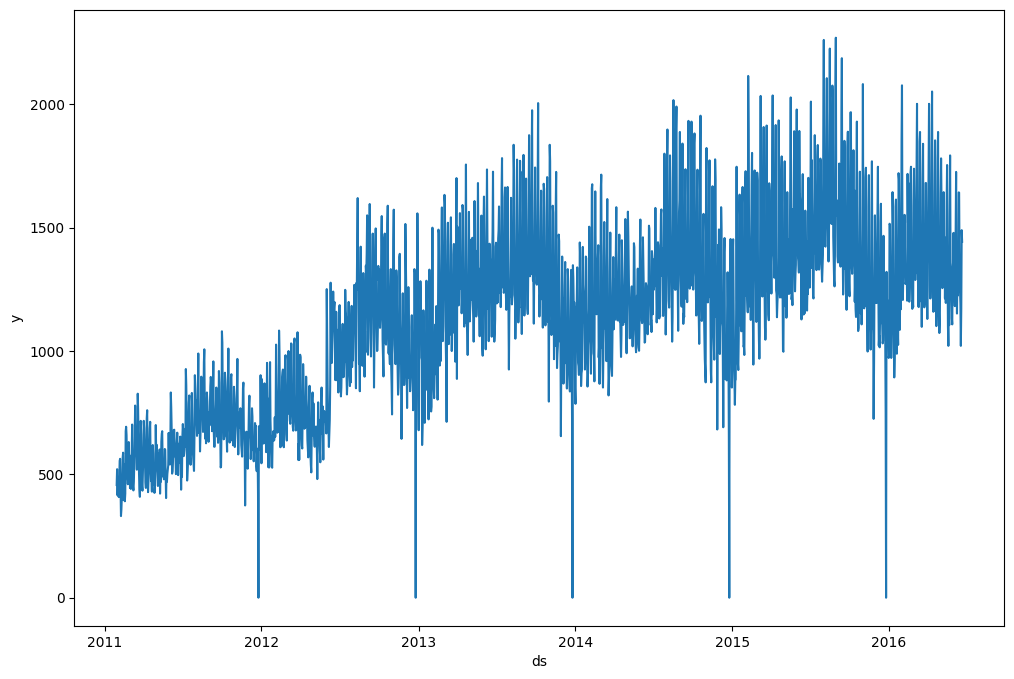

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
sns.lineplot(
    df,x='ds',y='y',ax=ax
)

In [ ]:
HORIZON = 90
df_train = df.iloc[:-HORIZON,:]
df_test = df.iloc[-HORIZON:,:]

In [ ]:
model_arima = ARIMA(
    endog=df_train['y'],
    order=(3,1,3)
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
model_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1879
Model:                 ARIMA(3, 1, 3)   Log Likelihood              -12060.126
Date:                Wed, 04 Mar 2026   AIC                          24134.253
Time:                        04:41:13   BIC                          24173.019
Sample:                    01-29-2011   HQIC                         24148.532
                         - 03-21-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4042      0.031     45.828      0.000       1.344       1.464
ar.L2         -1.1952      0.038    -31.308      0.000      -1.270      -1.120
ar.L3          0.1572      0.031      5.129      0.000       0.097       0.217
ma.L1         -2.1280      0.019   -111.857      0.000      -2.165      -2.091
ma.L2          2.0874      0.024     85.881      0.000       2.040       2.135
ma.L3         -0.8686      0.019    -46.303      0.000      -0.905      -0.832
sigma2      2.954e+04    750.140     39.374      0.000    2.81e+04     3.1e+04
===================================================================================
Ljung-Box (L1) (Q):                   1.09   Jarque-Bera (JB):              1890.30
Prob(Q):                              0.30   Prob(JB):                         0.00
Heteroskedasticity (H):               3.17   Skew:                            -0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
forecast_res = model_arima.get_forecast(steps=len(df_test))

In [ ]:
pred_mean = forecast_res.predicted_mean

In [ ]:
pred_mean

,predicted_mean
2016-03-22,1294.990267
2016-03-23,1167.816666
2016-03-24,1206.975710
2016-03-25,1399.496555
2016-03-26,1603.043920
...,...
2016-06-15,1183.994437
2016-06-16,1212.643054
2016-06-17,1393.512929
2016-06-18,1590.411459


In [ ]:
pred_ci = forecast_res.conf_int(alpha=0.05)

In [ ]:
pred_ci

,lower y,upper y
2016-03-22,958.150958,1631.829576
2016-03-23,818.360355,1517.272976
2016-03-24,853.782582,1560.168838
2016-03-25,1043.537422,1755.455689
2016-03-26,1244.103029,1961.984810
...,...,...
2016-06-15,618.565175,1749.423699
2016-06-16,645.468778,1779.817331
2016-06-17,824.682966,1962.342892
2016-06-18,1019.727116,2161.095801


In [ ]:
df_forecast_arima = pd.concat([df_test,pred_mean,pred_ci],axis=1)

In [ ]:
df_forecast_arima.index.name = 'ds'

In [ ]:
df_forecast_arima

,aggregate_id,category,state,y,weekday,day_cat,predicted_mean,lower y,upper y
ds,,,,,,,,,
2016-03-22,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1229.0,1,Weekday,1294.990267,958.150958,1631.829576
2016-03-23,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1177.0,2,Weekday,1167.816666,818.360355,1517.272976
2016-03-24,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1191.0,3,Weekday,1206.975710,853.782582,1560.168838
2016-03-25,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1301.0,4,Weekday,1399.496555,1043.537422,1755.455689
2016-03-26,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1681.0,5,Holiday,1603.043920,1244.103029,1961.984810
...,...,...,...,...,...,...,...,...,...
2016-06-15,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1192.0,2,Weekday,1183.994437,618.565175,1749.423699
2016-06-16,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1021.0,3,Weekday,1212.643054,645.468778,1779.817331
2016-06-17,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1171.0,4,Weekday,1393.512929,824.682966,1962.342892


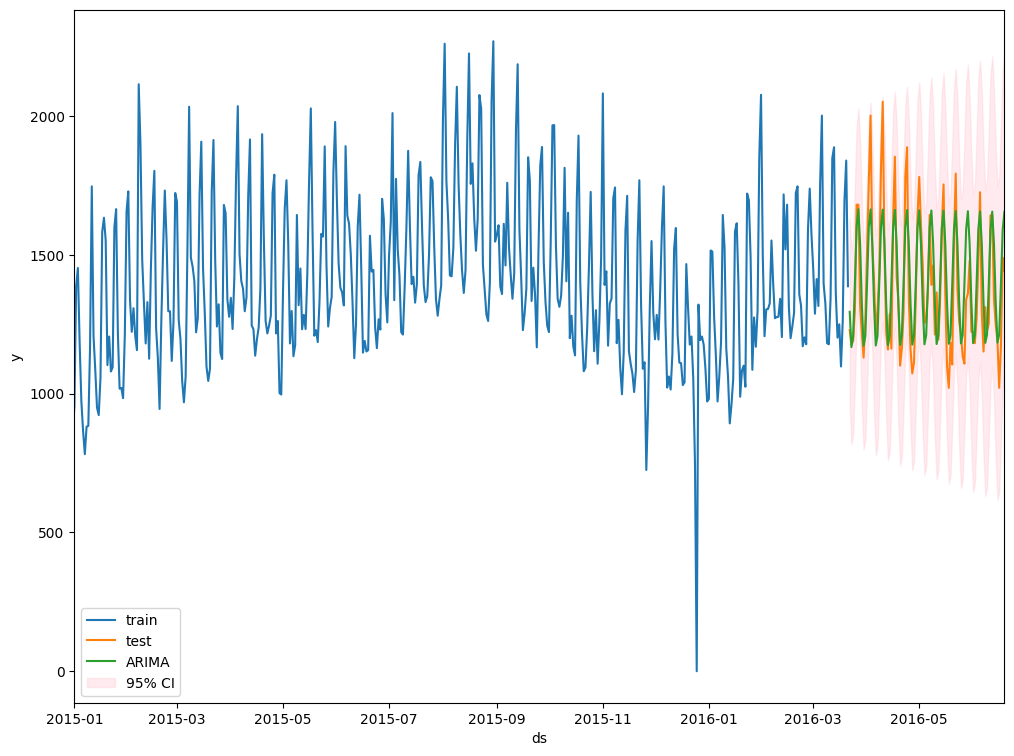

In [ ]:
fig,ax=plt.subplots(figsize=(12,9))
sns.lineplot(df_train,x='ds',y='y',label='train',ax=ax)
sns.lineplot(df_test,x='ds',y='y',label='test',ax=ax)
sns.lineplot(df_forecast_arima,x='ds',y='predicted_mean',label='ARIMA',ax=ax)
ax.fill_between(df_forecast_arima.index,
                df_forecast_arima.loc[:,'lower y'],
                df_forecast_arima.loc[:,'upper y'],
                color='pink',alpha=0.3,label='95% CI')
ax.set_xlim(pd.Timestamp('2015-01-01'),df_forecast_arima.index.max())
ax.legend()
plt.show()

# SARIMAX

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
file_path = './M5.csv'
df_m5 = pd.read_csv(file_path,parse_dates=['ds'],index_col=0)

target_id = 'HOUSEHOLD_1_CA_3'

df = df_m5.query('aggregate_id == @target_id').copy()
df['month'] = df['ds'].dt.month
df = df.set_index('ds')


In [ ]:
df

,aggregate_id,category,state,y,weekday,day_cat,month
ds,,,,,,,
2011-01-29,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,457.0,5,Holiday,1
2011-01-30,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,521.0,6,Holiday,1
2011-01-31,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,415.0,0,Weekday,1
2011-02-01,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,480.0,1,Weekday,2
2011-02-02,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,420.0,2,Weekday,2
...,...,...,...,...,...,...,...
2016-06-15,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1192.0,2,Weekday,6
2016-06-16,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1021.0,3,Weekday,6
2016-06-17,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1171.0,4,Weekday,6


In [ ]:
df['weekday'] = df['weekday'].astype(int)
X_weekday = pd.get_dummies(df['weekday'],prefix='weekday',drop_first = True,dtype=float)
X_month = pd.get_dummies(df['month'],prefix='month',drop_first = True,dtype=float)

df_concat = pd.concat([df,X_weekday,X_month],axis=1)

In [ ]:
df_concat

,aggregate_id,category,state,y,weekday,day_cat,month,weekday_1,weekday_2,weekday_3,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-29,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,457.0,5,Holiday,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-30,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,521.0,6,Holiday,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-31,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,415.0,0,Weekday,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-01,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,480.0,1,Weekday,2,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-02,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,420.0,2,Weekday,2,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-06-15,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1192.0,2,Weekday,6,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-06-16,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1021.0,3,Weekday,6,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-06-17,HOUSEHOLD_1_CA_3,HOUSEHOLD,CA,1171.0,4,Weekday,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
exog_cols=list(X_weekday.columns)+list(X_month.columns)

In [ ]:
exog_cols

['weekday_1',
 'weekday_2',
 'weekday_3',
 'weekday_4',
 'weekday_5',
 'weekday_6',
 'month_2',
 'month_3',
 'month_4',
 'month_5',
 'month_6',
 'month_7',
 'month_8',
 'month_9',
 'month_10',
 'month_11',
 'month_12']

In [ ]:
HORIZON = 90
df_train = df_concat.iloc[:-HORIZON,:]
df_test = df_concat.iloc[-HORIZON:,:]

In [ ]:
model_sarimax = SARIMAX(
    df_train['y'],
    exog=df_train[exog_cols],
    order=(3,1,3),
    seasonal_order=(1,0,1,30)
).fit(maxiter=1000)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
model_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                 1879
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 30)   Log Likelihood              -11865.448
Date:                              Wed, 04 Mar 2026   AIC                          23782.896
Time:                                      07:56:01   BIC                          23926.883
Sample:                                  01-29-2011   HQIC                         23835.933
                                       - 03-21-2016                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
weekday_1   -123.9725     34.264     -3.618      0.000    -191.130     -56.815
weekday_2   -172.9849     62.752     -2.757      0.006    -295.978     -49.992
weekday_3   -193.1981     80.787     -2.391      0.017    -351.538     -34.858
weekday_4    -94.1923     81.355     -1.158      0.247    -253.645      65.260
weekday_5    184.9033     63.339      2.919      0.004      60.762     309.045
weekday_6    230.9908     33.971      6.800      0.000     164.409     297.572
month_2     -113.2567     28.756     -3.938      0.000    -169.618     -56.895
month_3     -158.2564     42.253     -3.745      0.000    -241.071     -75.442
month_4      -57.1603     51.261     -1.115      0.265    -157.630      43.310
month_5      -63.7324     57.869     -1.101      0.271    -177.154      49.690
month_6      -98.5686     59.968     -1.644      0.100    -216.103      18.966
month_7      -81.9526     60.923     -1.345      0.179    -201.359      37.454
month_8      -68.4534     60.533     -1.131      0.258    -187.097      50.190
month_9     -155.4804     59.830     -2.599      0.009    -272.746     -38.215
month_10    -146.7656     54.220     -2.707      0.007    -253.035     -40.497
month_11     132.9107     43.811      3.034      0.002      47.043     218.778
month_12     188.3105     26.822      7.021      0.000     135.741     240.880
ar.L1          1.4046      0.028     50.325      0.000       1.350       1.459
ar.L2         -1.1949      0.035    -34.196      0.000      -1.263      -1.126
ar.L3          0.1586      0.028      5.746      0.000       0.104       0.213
ma.L1         -2.0297      0.023    -87.837      0.000      -2.075      -1.984
ma.L2          1.9500      0.031     61.954      0.000       1.888       2.012
ma.L3         -0.7740      0.023    -34.205      0.000      -0.818      -0.730
ar.S.L30       0.3947      0.426      0.927      0.354      -0.440       1.229
ma.S.L30      -0.3482      0.436     -0.798      0.425      -1.203       0.507
sigma2      1.789e+04    300.934     59.457      0.000    1.73e+04    1.85e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):              4305.52
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               2.27   Skew:                            -0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
forecast_res = model_sarimax.get_forecast(steps=len(df_test),
exog=df_test[exog_cols])
pred_mean = forecast_res.predicted_mean
pred_ci = forecast_res.conf_int(alpha=0.05)
df_forecast_sarimax = pd.concat([df_test,pred_mean,pred_ci],axis=1)
df_forecast_sarimax.index.name = 'ds'

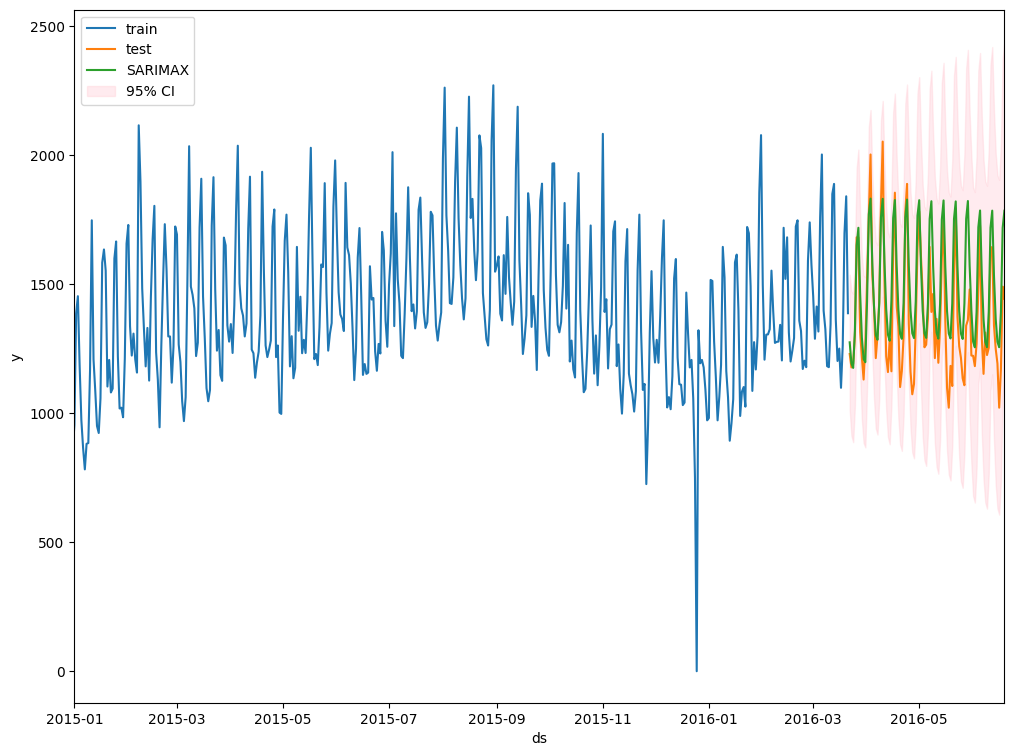

In [ ]:
fig,ax=plt.subplots(figsize=(12,9))
sns.lineplot(df_train,x='ds',y='y',label='train',ax=ax)
sns.lineplot(df_test,x='ds',y='y',label='test',ax=ax)
sns.lineplot(df_forecast_sarimax,x='ds',y='predicted_mean',label='SARIMAX',ax=ax)
ax.fill_between(df_forecast_sarimax.index,
                df_forecast_sarimax.loc[:,'lower y'],
                df_forecast_sarimax.loc[:,'upper y'],
                color='pink',alpha=0.3,label='95% CI')
ax.set_xlim(pd.Timestamp('2015-01-01'),df_forecast_sarimax.index.max())
ax.legend()
plt.show()